In [10]:
# Cargamos librerías
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

import os
import glob
from datetime import datetime, timedelta
import pandas as pd
import geopandas as gpd


import shutil

import ast
from collections import Counter
import intake

import json
from pathlib import Path
# import mlcast_datasets

from pyproj import CRS, Transformer
import tempfile
import fiona

import tqdm
import re
import rasterio
from rasterio.merge import merge
from rasterio.transform import Affine
from rasterio.windows import from_bounds
from scipy.ndimage import distance_transform_edt


# from whitebox import WhiteboxTools

In [ ]:
import xarray as xr
file_path = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part01\\chimanimani_s1asc_63.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds = xr.open_dataset(file_path)

print(ds)

In [ ]:
print(ds.data_vars)

In [ ]:
import matplotlib.pyplot as plt

vv = ds['VV']  # nombre puede variar

# Seleccionamos timestamp 0
img0 = vv.isel(time=0)

plt.imshow(img0, cmap='gray')
plt.colorbar()
plt.title("VV - time 0")
plt.show()

In [ ]:
pixel = vv[:, 64, 64]  # centro del patch

plt.plot(pixel)
plt.title("Evolución temporal VV")
plt.show()

In [ ]:
file_path = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part01\\chimanimani_s1asc_64.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds = xr.open_dataset(file_path)

print(ds)
print(ds.data_vars)


vv = ds['VV']  # nombre puede variar

# Seleccionamos timestamp 0
img0 = vv.isel(time=0)

plt.imshow(img0, cmap='gray')
plt.colorbar()
plt.title("VV - time 0")
plt.show()

pixel = vv[:, 64, 64]  # centro del patch

plt.plot(pixel)
plt.title("Evolución temporal VV")
plt.show()

In [ ]:
Dem = ds["DEM"]  # o ds["DEM"] según el nombre
Dem_t0 = Dem.isel(time=0)      # si la dimensión se llama "time"
# mask_t0 = mask.isel(t=0)       # si se llama "t" (alternativa)

plt.imshow(Dem_t0, cmap="terrain")
plt.title("DEM (time=0)")
plt.colorbar()
plt.show()

In [ ]:
file_path = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part01\\chimanimani_s1asc_747.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds = xr.open_dataset(file_path)

mask = ds["MASK"]  # o ds["MASK"] según el nombre

mask_t0 = mask.isel(time=0)      # si la dimensión se llama "time"
# mask_t0 = mask.isel(t=0)       # si se llama "t" (alternativa)

plt.imshow(mask_t0, cmap="Reds", vmin=0, vmax=1)
plt.title("MASK (time=0)")
plt.colorbar()
plt.show()

In [ ]:
Dem = ds["DEM"]  # o ds["DEM"] según el nombre
Dem_t0 = Dem.isel(time=0)      # si la dimensión se llama "time"
# mask_t0 = mask.isel(t=0)       # si se llama "t" (alternativa)

plt.imshow(Dem_t0, cmap="terrain")
plt.title("DEM (time=0)")
plt.colorbar()
plt.show()

In [ ]:
import numpy as np

mask = ds["MASK"]

print(np.all(mask[0] == mask[1]))
print(np.all(mask[0] == mask[14]))

In [ ]:
print(mask_t0.min().values, mask_t0.max().values)

In [ ]:
import numpy as np

mask = ds["MASK"]

print("Shape:", mask.shape)
print("Min:", mask.min().values)
print("Max:", mask.max().values)
print("Mean:", mask.mean().values)

In [ ]:
file_path = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part01\\chimanimani_s1asc_747.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds = xr.open_dataset(file_path)

print(ds)
print(ds.data_vars)


vv = ds['VV']  # nombre puede variar

# Seleccionamos timestamp 0
img0 = vv.isel(time=11)

plt.imshow(img0, cmap='gray')
plt.colorbar()
plt.title("VV - time 8")
plt.show()

pixel = vv[:, 64, 64]  # centro del patch

plt.plot(pixel)
plt.title("Evolución temporal VV")
plt.show()

In [ ]:
Dem = ds["DEM"]  # o ds["DEM"] según el nombre
Dem_t0 = Dem.isel(time=0)      # si la dimensión se llama "time"
# mask_t0 = mask.isel(t=0)       # si se llama "t" (alternativa)

plt.imshow(Dem_t0, cmap="terrain")
plt.title("DEM (time=0)")
plt.colorbar()
plt.show()

VALE BUENO VAMOS CON SENTINEL-2

In [ ]:
file_path1 = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s2_part01\\chimanimani_s2_101.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds1 = xr.open_dataset(file_path1)

print(ds1)
print(ds1.data_vars)

In [ ]:
vv1 = ds1['SCL']  # nombre puede variar

# Seleccionamos timestamp 0
img0 = vv1.isel(time=0)

plt.imshow(img0, cmap='gray')
plt.colorbar()
plt.title("B02 - time 0")
plt.show()

pixel = vv1[:, 64, 64]  # centro del patch

plt.plot(pixel)
plt.title("Evolución temporal B02")
plt.show()

In [ ]:
Dem = ds1["DEM"]  # o ds["DEM"] según el nombre
Dem_t0 = Dem.isel(time=0)      # si la dimensión se llama "time"
# mask_t0 = mask.isel(t=0)       # si se llama "t" (alternativa)

plt.imshow(Dem_t0, cmap="terrain")
plt.title("DEM (time=0)")
plt.colorbar()
plt.show()

In [ ]:
file_path1 = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part01\\chimanimani_s1asc_1318.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds1 = xr.open_dataset(file_path1)

print(ds1)
print(ds1.data_vars)
# vamos a visualizar la variable 'MASK'
mask = ds1['MASK']
plt.imshow(mask[0], cmap="Reds", vmin=0, vmax=1)

plt.title("MASK (time=0)")
plt.show()

In [ ]:
file_path1 = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part01\\chimanimani_s1asc_1622.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds1 = xr.open_dataset(file_path1)

print(ds1)
print(ds1.data_vars)
# vamos a visualizar la variable 'MASK'
mask = ds1['MASK']
plt.imshow(mask[0], cmap="Reds", vmin=0, vmax=1)

plt.title("MASK (time=0)")
plt.show()

In [ ]:
print(ds1.attrs)
# imprimir el valor del diccionario ds1.attrs cuya clave es "pre_post_dates"
print("pre_post_dates:", ds1.attrs["pre_post_dates"])
# Ahora imprimir el tipo de dato del valor asociado a esa clave
print("Tipo de dato de pre_post_dates:", type(ds1.attrs["pre_post_dates"]))
import ast

pre_post = ast.literal_eval(ds1.attrs["pre_post_dates"])

print(pre_post)
print(type(pre_post))

COMPROBACIÓN DE COHERENCIA Y COHESIÓN DE FECHAS Y TIMESTAMPS

In [ ]:
print(pre_post)
print(type(pre_post))

files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\*.nc")

vals = []

for f in files:
    ds = xr.open_dataset(f)
    pre_post = ds.attrs["pre_post_dates"]
    pre_post = ast.literal_eval(ds1.attrs["pre_post_dates"])
    vals.append((pre_post["pre"], pre_post["post"]))
    ds.close()

print(Counter(vals))

In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1dsc_part01\*.nc")

vals = []

for f in files:
    ds = xr.open_dataset(f)
    pre_post = ds.attrs["pre_post_dates"]
    pre_post = ast.literal_eval(ds1.attrs["pre_post_dates"])
    vals.append((pre_post["pre"], pre_post["post"]))
    ds.close()

print(Counter(vals))

In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s2_part01\*.nc")

vals = []

for f in files:
    ds = xr.open_dataset(f)
    pre_post = ds.attrs["pre_post_dates"]
    pre_post = ast.literal_eval(ds1.attrs["pre_post_dates"])
    vals.append((pre_post["pre"], pre_post["post"]))
    ds.close()

print(Counter(vals))

Chimanimani747 para asc tiene pre 6 y post 7, mientras que para dsc tiene 7 pre y post 8. Sin embargo la evolución temporal de asc cambia en las 15 divisiones. 

Por alguna razón, hay muchas zonas que no tienen información sobre los atributos: confianza de la fecha, pre_post_dates, etc... Por otro lado, parece ser que asc siempre tiene 6 pre y 7 post, mientras que dsc tiene 7 pre y 8 post. Espera un momento, puede que sea porque no hay evento?

Confirmamos. Ahora, confirmar que haya coherencia en la división. 

In [ ]:
file_path = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part05\\italy_s1asc_207.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part05\italy_s1asc_149.nc
ds = xr.open_dataset(file_path)

print(ds)
print(ds.data_vars)


vv = ds['VV']  # nombre puede variar

# Seleccionamos timestamp 0
img0 = vv.isel(time=0)

plt.imshow(img0, cmap='gray')
plt.colorbar()
plt.title("VV - time 0")
plt.show()

pixel = vv[:, 64, 64]  # centro del patch

plt.plot(pixel)
plt.title("Evolución temporal VV")
plt.show()

Dem = ds["DEM"]  # o ds["DEM"] según el nombre
Dem_t0 = Dem.isel(time=0)      # si la dimensión se llama "time"
# mask_t0 = mask.isel(t=0)       # si se llama "t" (alternativa)

plt.imshow(Dem_t0, cmap="terrain")
plt.title("DEM (time=0)")
plt.colorbar()
plt.show()
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
ds = xr.open_dataset(file_path)

mask = ds["MASK"]  # o ds["MASK"] según el nombre

mask_t0 = mask.isel(time=0)      # si la dimensión se llama "time"
# mask_t0 = mask.isel(t=0)       # si se llama "t" (alternativa)

plt.imshow(mask_t0, cmap="Reds", vmin=0, vmax=1)
plt.title("MASK (time=0)")
plt.colorbar()
plt.show()

COMPROBACIÓN de que la igualdad de enumeración de asc y dsc significa la igualdad entre coordenadas

In [ ]:
file_path = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part01\\chimanimani_s1asc_63.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part01\chimanimani_s1asc_63.nc
file_path1 = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1dsc_part01\\chimanimani_s1dsc_63.nc'

chima_asc = xr.open_dataset(file_path)
chima_dsc = xr.open_dataset(file_path1)
# Ahora vamos a comprobar que el atributo coordenates de ambos datasets es el mismo
print("Coordenadas chima_asc:", chima_asc.coords)
print("Coordenadas chima_dsc:", chima_dsc.coords)
# ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all(), hay que usar np.array_equal para comparar arrays
import numpy as np
if np.array_equal(chima_asc.coords, chima_dsc.coords):
    print("Las coordenadas son iguales en ambos datasets.")



SELECCIÓN DE ZONAS
Lo más astuto será elegir zonas que dispongan de las variables externas. Se estaba considerando elegir chimanimani de Zimbabwe, pero tiene pinta que será complicado encontrar fuentes que proporcionen estas variables externas. El país que seguro que se selecciona es Italia, y quizás entre Nueva zelanda y la India. 

COMPROBACIÓN EN OTRA ZONA

VALE, ahora comprobaciones que hay que hacer: En primer lugar, comprobar cuantas zonas o patches contienen tanto asc, como dsc, como Sentinel2. Y la otra comprobación es que de esos patches, comprobar que no haya representaciones faltantes. 

Empecemos por comprobar cuantos patches tienen máscara deslizamiento = 1, en una única parte. 

In [19]:
files = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part08\*.nc")
count = 0
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1

print(f"Number of .nc files with MASK = 1: {count}")

Number of .nc files with MASK = 1: 550


In [6]:
ds = xr.open_dataset(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part07\italy_s1asc_373.nc")

In [20]:

files = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1dsc_part07\*.nc")
count = 0
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1

print(f"Number of .nc files with MASK = 1: {count}")

Number of .nc files with MASK = 1: 543


In [27]:
# Ahora contar cuantos nc de asc tienen la misma enumeración que los nc de dsc

files = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part08\*.nc")
files1 = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1dsc_part07\*.nc")
asc_nums = set()
for f in files:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    asc_nums.add(num)
dsc_nums = set()
for f in files1:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    dsc_nums.add(num)

matching_nums = asc_nums.intersection(dsc_nums)
print(f"Number of matching .nc files in asc and dsc: {len(matching_nums)}")
print(f"Matching numbers: {matching_nums}")


Number of matching .nc files in asc and dsc: 858
Matching numbers: {'6530', '5935', '6115', '5936', '6180', '6539', '6242', '5615', '5358', '6311', '6411', '6392', '5458', '5421', '628', '5946', '624', '5948', '6229', '5578', '5638', '5736', '6442', '6526', '5672', '6113', '5870', '6130', '6387', '5684', '5824', '6534', '6053', '6444', '6447', '5419', '5517', '6431', '5745', '5443', '5565', '5354', '5941', '5951', '5441', '5959', '6450', '645', '6265', '5544', '5708', '5799', '5501', '6135', '6025', '600', '6078', '613', '5624', '6065', '5782', '5896', '5435', '5382', '5947', '6268', '5653', '5650', '635', '5944', '6239', '6323', '5865', '5678', '6410', '6234', '6344', '5399', '5995', '6399', '6237', '5506', '5503', '5639', '6042', '646', '5494', '5732', '5806', '5885', '5408', '6295', '6401', '5750', '6491', '598', '6504', '5726', '5871', '6165', '5988', '6382', '5729', '6484', '6238', '5823', '6371', '563', '588', '6320', '6535', '5764', '6296', '5857', '6189', '6271', '5957', '6081'

In [28]:
# -----------------------------
# Paths
# -----------------------------

asc_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part08"
dsc_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1dsc_part07"

# -----------------------------
# Archivos
# -----------------------------

files_asc = glob.glob(os.path.join(asc_dir, "*.nc"))
files_dsc = glob.glob(os.path.join(dsc_dir, "*.nc"))

# # -----------------------------
# # IDs
# # -----------------------------

# asc_nums = set()
# for f in files_asc:
#     num = f.split("_")[-1].split(".")[0]
#     asc_nums.add(num)

# dsc_nums = set()
# for f in files_dsc:
#     num = f.split("_")[-1].split(".")[0]
#     dsc_nums.add(num)

# matching_nums = asc_nums.intersection(dsc_nums)

# print(f"Matching IDs: {len(matching_nums)}")

# -----------------------------
# Buscar positivos
# -----------------------------

positive_matching_nums = set()

for num in matching_nums:

    asc_path = os.path.join(
        asc_dir,
        f"italy_s1asc_{num}.nc"
    )

    try:
        ds = xr.open_dataset(asc_path)

        mask = ds["MASK"].values

        if mask.max() == 1:
            positive_matching_nums.add(num)

        ds.close()

    except Exception as e:
        print(f"Error con {num}: {e}")

# -----------------------------
# Resultados
# -----------------------------

print(f"\nMatching positivos: {len(positive_matching_nums)}")
print(positive_matching_nums)


Matching positivos: 478
{'6530', '5935', '5936', '6180', '6539', '6242', '5358', '6311', '6392', '5421', '5946', '5948', '6229', '5578', '5638', '5736', '6526', '5870', '6387', '6534', '5517', '5443', '5565', '5354', '5941', '5951', '5441', '5959', '6450', '5799', '5501', '6025', '5435', '5947', '5653', '5650', '635', '5944', '6239', '6323', '5865', '6234', '6399', '6237', '5506', '5503', '5639', '646', '5494', '5732', '5806', '5885', '5726', '5871', '6165', '6382', '5729', '6238', '6320', '6535', '6081', '580', '576', '5861', '6466', '5432', '6178', '5939', '5642', '5800', '6161', '6381', '5866', '5804', '6248', '6094', '5722', '6243', '6244', '5359', '5429', '5438', '5361', '5567', '6017', '6093', '6543', '5491', '5788', '5370', '5364', '5586', '5809', '6024', '6377', '653', '6468', '5352', '6105', '5792', '651', '5961', '6461', '6529', '5422', '582', '6253', '5373', '6174', '6306', '5934', '5516', '569', '6460', '640', '6096', '633', '6532', '5796', '6471', '6100', '5579', '5657', 

In [29]:
positive_dense_nums = set()

positive_ratios = {}

for num in positive_matching_nums:

    asc_path = os.path.join(
        asc_dir,
        f"italy_s1asc_{num}.nc"
    )

    try:
        ds = xr.open_dataset(asc_path)

        mask = ds["MASK"].values

        # quitar dimensión temporal si existe
        if mask.ndim == 3:
            mask = mask[0]

        positives = (mask == 1).sum()
        total = mask.size

        ratio = positives / total

        positive_ratios[num] = ratio

        if ratio > 0.02:
            positive_dense_nums.add(num)

        ds.close()

    except Exception as e:
        print(f"Error con {num}: {e}")

print(f"\nPatches con >2% positivos: {len(positive_dense_nums)}")
print(positive_dense_nums)


Patches con >2% positivos: 217
{'6530', '5724', '5581', '5725', '5357', '6312', '6028', '6469', '5511', '6015', '5585', '5358', '6311', '6392', '6012', '6456', '5946', '6386', '5879', '5948', '5578', '5436', '6175', '6016', '6317', '5588', '5870', '6097', '5663', '5940', '6387', '6534', '6091', '5509', '6249', '5791', '5941', '5951', '6159', '5441', '5439', '5659', '5508', '5798', '5799', '5363', '6310', '5661', '5877', '5874', '6309', '5365', '5360', '5868', '6027', '5435', '6090', '5947', '6173', '5653', '5650', '5505', '5944', '6239', '5655', '6384', '5434', '5865', '5950', '5797', '5433', '5356', '6383', '5662', '5875', '6234', '6235', '6095', '6237', '5506', '6308', '5732', '5582', '5806', '5942', '5955', '5805', '5945', '5807', '5651', '6166', '5952', '5733', '5726', '5871', '6165', '6022', '5729', '6238', '5873', '5366', '6240', '5876', '6535', '6459', '6177', '6540', '5367', '6088', '6466', '5432', '6531', '5939', '5800', '6161', '5883', '5866', '6393', '5510', '6385', '5730',

In [15]:
ds = xr.open_dataset(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part07\italy_s1asc_4484.nc")

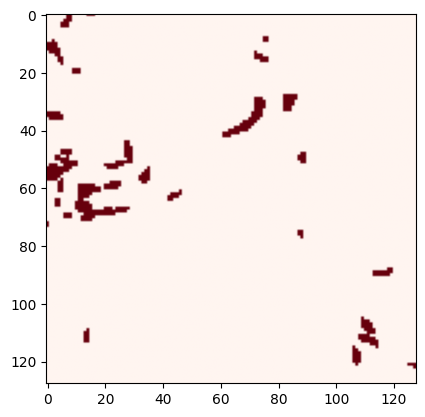

In [16]:
mask = ds["MASK"].isel(time=0).values
plt.imshow(mask, cmap="Reds", vmin=0, vmax=1)

In [ ]:
sen2_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s2_part13"

sen2_files = glob.glob(os.path.join(sen2_dir, "*.nc"))

# -----------------------------
# IDs Sen2
# -----------------------------

sen2_nums = set()

for f in sen2_files:
    num = f.split("_")[-1].split(".")[0]
    sen2_nums.add(num)

# -----------------------------
# Intersección
# -----------------------------

positive_dense_sen2_nums = positive_dense_nums.intersection(sen2_nums)

# -----------------------------
# Resultados
# -----------------------------

print(f"Patches densos presentes en Sen2: {len(positive_dense_sen2_nums)}")
print(positive_dense_sen2_nums)

Patches densos presentes en Sen2: 115
{'4484', '4556', '4406', '4547', '4555', '4046', '4557', '4194', '4047', '4478', '4403', '4481', '4192', '4119', '4408', '4335', '4190', '4117', '4549', '4036', '4043', '4402', '4185', '4257', '3975', '4476', '4409', '4109', '3966', '4479', '4114', '4254', '4477', '3968', '4113', '4480', '4269', '4341', '4116', '4111', '4268', '4108', '4328', '3972', '4188', '4561', '4485', '4041', '4184', '4258', '4333', '4405', '4179', '4410', '4120', '3969', '4330', '4183', '4400', '4044', '3967', '4483', '4267', '4040', '4186', '3965', '3960', '4266', '4552', '4262', '4035', '4554', '4256', '4342', '4550', '4334', '3971', '4482', '4411', '4118', '4259', '4187', '4263', '4486', '4260', '4407', '4553', '4412', '4045', '4181', '3962', '4331', '4551', '4121', '4110', '4032', '4112', '4255', '4038', '3964', '4034', '4338', '4042', '4329', '4337', '4560', '4196', '4336', '4182', '4332', '4039', '4404', '4401', '4037', '4475'}


In [18]:
sen2_dir = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s2_part14"

sen2_files = glob.glob(os.path.join(sen2_dir, "*.nc"))

# -----------------------------
# IDs Sen2
# -----------------------------

sen2_nums = set()

for f in sen2_files:
    num = f.split("_")[-1].split(".")[0]
    sen2_nums.add(num)

# -----------------------------
# Intersección
# -----------------------------

positive_dense_sen2_nums = positive_dense_nums.intersection(sen2_nums)

# -----------------------------
# Resultados
# -----------------------------

print(f"Patches densos presentes en Sen2: {len(positive_dense_sen2_nums)}")
print(positive_dense_sen2_nums)

Patches densos presentes en Sen2: 114
{'4627', '4636', '4990', '4776', '4704', '5072', '4842', '5071', '4852', '4919', '4634', '4770', '4623', '4927', '4994', '4774', '4620', '5145', '4761', '4917', '4922', '4999', '4780', '4926', '5143', '5138', '4782', '4998', '4772', '4631', '5000', '4703', '5069', '4925', '4997', '4628', '4695', '4775', '5140', '4708', '4846', '4700', '4624', '4851', '4916', '4924', '4992', '4777', '5063', '4845', '5075', '4762', '5137', '5074', '5066', '5146', '4625', '4995', '4705', '4630', '4850', '4921', '4632', '5076', '4928', '5061', '4988', '5059', '5065', '4847', '4841', '5070', '5068', '4626', '4694', '4853', '5064', '4920', '4773', '4713', '4629', '4843', '4844', '4698', '4986', '4771', '4701', '4915', '5002', '4918', '4697', '5141', '4996', '4706', '4991', '5139', '4778', '5001', '5144', '4702', '4849', '5062', '4848', '4993', '4989', '4699', '5067', '4769', '4857', '4779', '5142', '4913', '4987', '4923'}


Ahora pues supongo que convendría hacer una carpeta con esos archivos en concreto

In [31]:
# Ahora construimos una carpeta que tenga solo los nc de asc y dsc que tienen la misma enumeración, para luego hacer un análisis más detallado de esos casos concretos


output_folder = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files_2"
os.makedirs(output_folder, exist_ok=True)
# dentro de la carpeta vamos a crear 2 subcarpetas, una para asc y otra para dsc

asc_folder = os.path.join(output_folder, "asc")
dsc_folder = os.path.join(output_folder, "dsc")
os.makedirs(asc_folder, exist_ok=True)
os.makedirs(dsc_folder, exist_ok=True)
for num in positive_dense_nums:
    asc_file = f"C:\\Users\\gonra\\Documents\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1asc_part08\\italy_s1asc_{num}.nc"
    dsc_file = f"C:\\Users\\gonra\\Documents\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s1dsc_part07\\italy_s1dsc_{num}.nc"
    shutil.copy(asc_file, os.path.join(asc_folder, f"italy_s1asc_{num}.nc"))
    shutil.copy(dsc_file, os.path.join(dsc_folder, f"italy_s1dsc_{num}.nc"))



Y ahora vamos a contar cuantos patches tienen mask.max = 1

In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\asc\*.nc")
count = 0
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1

print(f"Number of .nc files with MASK = 1: {count}")

In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\dsc\*.nc")
count = 0
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1

print(f"Number of .nc files with MASK = 1: {count}")

Ahora tocaría comprobar que de estos nc ninguno tiene representaciones faltantes, bueno o antes vamos a juntar Sentinel-1 con Sentinel-2

In [41]:
files = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files_2\asc\*.nc")
files1 = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s2_part16\*.nc")
asc_nums = set()
for f in files:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    asc_nums.add(num)
dsc_nums = set()
for f in files1:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    dsc_nums.add(num)

matching_nums = asc_nums.intersection(dsc_nums)
print(f"Number of matching .nc files in asc and dsc: {len(matching_nums)}")
print(f"Matching numbers: {matching_nums}")
output_folder = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files_2"
os.makedirs(output_folder, exist_ok=True)
# dentro de la carpeta vamos a crear 2 subcarpetas, una para asc y otra para dsc

Sentinel2 = os.path.join(output_folder, "Sen2")
os.makedirs(Sentinel2, exist_ok=True)
for num in matching_nums:
        Sen2_file = f"C:\\Users\\gonra\\Documents\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s2_part16\\italy_s2_{num}.nc"
        shutil.copy(Sen2_file, os.path.join(Sentinel2, f"italy_s2_{num}.nc"))


Number of matching .nc files in asc and dsc: 90
Matching numbers: {'6530', '6312', '6028', '6469', '6015', '6311', '6392', '6456', '6386', '6175', '6016', '6317', '6097', '6387', '6534', '6091', '6249', '6159', '6310', '6309', '6027', '6090', '6173', '6239', '6384', '6383', '6234', '6235', '6095', '6237', '6308', '6166', '6165', '6022', '6238', '6240', '6535', '6459', '6177', '6540', '6088', '6466', '6531', '6161', '6393', '6385', '6248', '6023', '6094', '6394', '6017', '6093', '6543', '6468', '6024', '6020', '6395', '6162', '6313', '6464', '6102', '6098', '6461', '6246', '6092', '6174', '6026', '6457', '6018', '6160', '6460', '6087', '6089', '6541', '6532', '6163', '6167', '6391', '6176', '6533', '6164', '6316', '6019', '6099', '6458', '6538', '6171', '6021', '6236', '6467'}


In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\asc\*.nc")
files1 = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s2_part12\*.nc")
asc_nums = set()
for f in files:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    asc_nums.add(num)
dsc_nums = set()
for f in files1:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    dsc_nums.add(num)

matching_nums = asc_nums.intersection(dsc_nums)
print(f"Number of matching .nc files in asc and dsc: {len(matching_nums)}")
print(f"Matching numbers: {matching_nums}")

output_folder = r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files"
# dentro de la carpeta vamos a crear 2 subcarpetas, una para asc y otra para dsc

Sentinel2 = os.path.join(output_folder, "Sen2")
for num in matching_nums:
    Sen2_file = f"C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\s2_part12\\italy_s2_{num}.nc"
    shutil.copy(Sen2_file, os.path.join(Sentinel2, f"italy_s2_{num}.nc"))

In [44]:
# Vamos a contar cuantos nc de Sentinel 2 hay en la carpeta de matching files
files = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files_2\Sen2\*.nc")
print(f"Number of Sentinel 2 .nc files in matching_files: {len(files)}")

Number of Sentinel 2 .nc files in matching_files: 446


In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\Sen2\*.nc")
count = 0
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1

print(f"Number of .nc files with MASK = 1: {count}")

In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\asc\*.nc")
files1 = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s2_part09\*.nc")
asc_nums = set()
for f in files:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    asc_nums.add(num)
dsc_nums = set()
for f in files1:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    dsc_nums.add(num)

matching_nums = asc_nums.intersection(dsc_nums)


Faltan 23 archivos, y no parecen estar en la parte 13, estarán en la parte 10, o en la parte 9. Sin embargo, archivos con mask = 1, hay 481, igual que en asc y desc. 

Bueno no somos capaces de encontrar esos 23 archivos, pues se eliminan y ya esta. 

In [ ]:
# A continuación buscamos los archivos dentro de matching files Sen2 y asc que no coincidan en numero, y los eliminamos de asc
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\asc\*.nc")
files1 = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\Sen2\*.nc")
asc_nums = set()
for f in files:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    asc_nums.add(num)
dsc_nums = set()
for f in files1:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    dsc_nums.add(num)

matching_nums = asc_nums.intersection(dsc_nums)
print(f"Number of matching .nc files in asc and Sen2: {len(matching_nums)}")
print(f"Matching numbers: {matching_nums}")
# Y ahora eliminamos los archivos de asc que no estén en matching_nums
for f in files:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    if num not in matching_nums:
        os.remove(f)
print(f"Number of Sentinel 2 .nc files in matching_files: {len(files)}")
# Y lo mismo para los archivos de dsc que no estén en matching_nums


In [ ]:
files2 = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\dsc\*.nc")
files1 = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\Sen2\*.nc")
asc_nums = set()
for f in files:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    asc_nums.add(num)
dsc_nums = set()
for f in files1:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    dsc_nums.add(num)

matching_nums = asc_nums.intersection(dsc_nums)
print(f"Number of matching .nc files in asc and Sen2: {len(matching_nums)}")
print(f"Matching numbers: {matching_nums}")
for f in files2:
    num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
    if num not in matching_nums:
        os.remove(f)
print(f"Number of Sentinel 2 .nc files in matching_files: {len(files2)}")

Comprobación de cuantos mask = 1 tenemos

In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\asc\*.nc")
count = 0
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1

print(f"Number of .nc files with MASK = 1: {count}")

In [ ]:
files = glob.glob(r"C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\dsc\*.nc")
count = 0
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1

print(f"Number of .nc files with MASK = 1: {count}")

In [4]:
file_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\dsc\italy_s1dsc_250.nc"
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part05\italy_s1asc_149.nc
ds = xr.open_dataset(file_path)

print(ds)
print(ds.data_vars)

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 15, x: 128, y: 128)
Coordinates:
  * time         (time) datetime64[ns] 120B 2022-10-30 2022-11-23 ... 2023-08-14
  * x            (x) float64 1kB 6.387e+05 6.387e+05 ... 6.4e+05 6.4e+05
  * y            (y) float64 1kB 4.884e+06 4.884e+06 ... 4.883e+06 4.883e+06
Data variables:
    VH           (time, x, y) float32 983kB ...
    VV           (time, x, y) float32 983kB ...
    MASK         (time, x, y) uint8 246kB ...
    DEM          (time, x, y) int16 492kB ...
    spatial_ref  int64 8B ...
Attributes:
    ann_id:           
    ann_bbox:         
    event_date:       
    date_confidence:  
    pre_post_dates:   
    annotated:        False
    satellite:        s1-dsc
    center_lat:       4883840.0
    center_lon:       639360.0
    crs:              EPSG:32632
Data variables:
    VH           (time, x, y) float32 983kB ...
    VV           (time, x, y) float32 983kB ...
    MASK         (time, x, y) uint8 246kB ...
    DEM      

In [5]:
ds.close()

In [6]:
file_path = r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files\Sen2\italy_s2_250.nc"
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part05\italy_s1asc_149.nc
ds = xr.open_dataset(file_path)

print(ds)
print(ds.data_vars)

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 15, x: 128, y: 128)
Coordinates:
  * time         (time) datetime64[ns] 120B 2022-10-05 2022-10-30 ... 2023-09-10
  * x            (x) float64 1kB 6.387e+05 6.387e+05 ... 6.4e+05 6.4e+05
  * y            (y) float64 1kB 4.884e+06 4.884e+06 ... 4.883e+06 4.883e+06
Data variables: (12/14)
    B02          (time, x, y) int16 492kB ...
    B03          (time, x, y) int16 492kB ...
    B04          (time, x, y) int16 492kB ...
    B05          (time, x, y) int16 492kB ...
    B06          (time, x, y) int16 492kB ...
    B07          (time, x, y) int16 492kB ...
    ...           ...
    B11          (time, x, y) int16 492kB ...
    B12          (time, x, y) int16 492kB ...
    SCL          (time, x, y) int16 492kB ...
    MASK         (time, x, y) uint8 246kB ...
    DEM          (time, x, y) int16 492kB ...
    spatial_ref  int64 8B ...
Attributes:
    ann_id:           
    ann_bbox:         
    event_date:       
    date_confidence:  

In [7]:
ds.close()

Todo en orden, ahora comprobación de que no hay representaciones faltantes, en las variables MASK, DEM, y SCL.

In [45]:


folder = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\matching_files_2\\Sen2'

missing_dem = []
empty_dem = []
constant_dem = []
valid_dem = []

for file in os.listdir(folder):
    
    if not file.endswith(".nc"):
        continue

    path = os.path.join(folder, file)

    try:
        ds = xr.open_dataset(path)

        # comprobar si existe
        if "DEM" not in ds:
            missing_dem.append(file)
            continue

        dem = ds["DEM"].values

        # DEM todo NaN
        if np.isnan(dem).all():
            empty_dem.append((file, "DEM todo NaN"))
            continue

        # DEM todo 0
        if np.all(np.nan_to_num(dem) == 0):
            empty_dem.append((file, "DEM todo 0"))
            continue

        # DEM constante (sin relieve)
        if np.nanstd(dem) == 0:
            constant_dem.append(file)
            continue

        valid_dem.append(file)

    except Exception as e:
        print(f"Error leyendo {file}: {e}")

print("\n=== DEM AUSENTE ===")
print(len(missing_dem))
for f in missing_dem:
    print(f)

print("\n=== DEM VACÍO ===")
for f in empty_dem:
    print(f)

print("\n=== DEM CONSTANTE ===")
for f in constant_dem:
    print(f)

print("\n=== DEM VÁLIDO ===")
print(len(valid_dem))


=== DEM AUSENTE ===
0

=== DEM VACÍO ===

=== DEM CONSTANTE ===

=== DEM VÁLIDO ===
0


In [46]:

import numpy as np

folder = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\matching_files_2\\dsc'

missing_mask = []
empty_mask = []
valid_mask = []

for file in os.listdir(folder):
    
    if not file.endswith(".nc"):
        continue

    path = os.path.join(folder, file)

    try:
        ds = xr.open_dataset(path)

        # comprobar si existe
        if "MASK" not in ds:
            missing_mask.append(file)
            continue

        dem = ds["MASK"].values

        # MASK todo NaN
        if np.isnan(dem).all():
            empty_mask.append((file, "MASK todo NaN"))
            continue



        valid_mask.append(file)

    except Exception as e:
        print(f"Error leyendo {file}: {e}")

print("\n=== MASK AUSENTE ===")
print(len(missing_mask))
for f in missing_mask:
    print(f)

print("\n=== MASK VACÍO ===")
for f in empty_mask:
    print(f)

print("\n=== MASK VÁLIDO ===")
print(len(valid_mask))


=== MASK AUSENTE ===
0

=== MASK VACÍO ===

=== MASK VÁLIDO ===
0


In [47]:


folder = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\matching_files_2\\Sen2'

missing_scl = []
nan_scl = []
nodata_scl = []
valid_scl = []

for file in os.listdir(folder):

    if not file.endswith(".nc"):
        continue

    path = os.path.join(folder, file)

    try:
        ds = xr.open_dataset(path)

        if "SCL" not in ds:
            missing_scl.append(file)
            continue

        scl = ds["SCL"].values

        # todo NaN
        if np.isnan(scl).all():
            nan_scl.append(file)
            continue

        # todo 0 (no data)
        if np.all(np.nan_to_num(scl) == 0):
            nodata_scl.append(file)
            continue

        valid_scl.append(file)

    except Exception as e:
        print(f"Error leyendo {file}: {e}")

print("\nSCL AUSENTE:", len(missing_scl))
print("SCL TODO NaN:", len(nan_scl))
print("SCL TODO 0:", len(nodata_scl))
print("SCL VÁLIDO:", len(valid_scl))


SCL AUSENTE: 0
SCL TODO NaN: 0
SCL TODO 0: 0
SCL VÁLIDO: 0


In [ ]:
file_path = 'C:\\Windows.old\\Users\\gonra\\OneDrive\\Documentos\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\matching_files\\Sen2\\italy_s2_250.nc'
# C:\Windows.old\Users\gonra\OneDrive\Documentos\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\s1asc_part05\italy_s1asc_149.nc
ds = xr.open_dataset(file_path)
# visualizamos la variable SCL
scl = ds["SCL"]
plt.imshow(scl[0], cmap="tab20")    
plt.title("SCL (time=0)")
plt.colorbar()
plt.show()
print(ds)
print(ds['time'])


In [49]:

gdf = gpd.read_file("C:\\Users\\gonra\\Documents\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\patch_locations_aligned.geojson")
# Visualicemos el GeoDataFrame
# print(gdf)

In [51]:
folder = "C:\\Users\\gonra\\Documents\\NEW DEGREE YESSIR\\4RTO CURSO\\2NDOSEMESTRE\\TFG\\FREESTYLE_FOLDER\\matching_files_2\\asc"

patches = [f.replace(".nc","") for f in os.listdir(folder) if f.endswith(".nc")]
print(patches)
# Ahora reemplazamos 's1asc_' por ''
patches = [p.replace("s1asc_", "") for p in patches]
print(patches)

['italy_s1asc_3960', 'italy_s1asc_3962', 'italy_s1asc_3964', 'italy_s1asc_3965', 'italy_s1asc_3966', 'italy_s1asc_3967', 'italy_s1asc_3968', 'italy_s1asc_3969', 'italy_s1asc_3971', 'italy_s1asc_3972', 'italy_s1asc_3975', 'italy_s1asc_4032', 'italy_s1asc_4034', 'italy_s1asc_4035', 'italy_s1asc_4036', 'italy_s1asc_4037', 'italy_s1asc_4038', 'italy_s1asc_4039', 'italy_s1asc_4040', 'italy_s1asc_4041', 'italy_s1asc_4042', 'italy_s1asc_4043', 'italy_s1asc_4044', 'italy_s1asc_4045', 'italy_s1asc_4046', 'italy_s1asc_4047', 'italy_s1asc_4108', 'italy_s1asc_4109', 'italy_s1asc_4110', 'italy_s1asc_4111', 'italy_s1asc_4112', 'italy_s1asc_4113', 'italy_s1asc_4114', 'italy_s1asc_4116', 'italy_s1asc_4117', 'italy_s1asc_4118', 'italy_s1asc_4119', 'italy_s1asc_4120', 'italy_s1asc_4121', 'italy_s1asc_4179', 'italy_s1asc_4181', 'italy_s1asc_4182', 'italy_s1asc_4183', 'italy_s1asc_4184', 'italy_s1asc_4185', 'italy_s1asc_4186', 'italy_s1asc_4187', 'italy_s1asc_4188', 'italy_s1asc_4190', 'italy_s1asc_4192',

In [52]:
# Y ahora filtramos
gdf_filtered = gdf[gdf["patch_id"].isin(patches)]
print(gdf_filtered)

        patch_id  split inventory  annotated_pixels        lon        lat  \
2116  italy_3960  train     italy               485  11.544789  44.194634   
2118  italy_3962   test     italy               660  11.545781  44.217659   
2120  italy_3964  train     italy               373  11.546774  44.240685   
2121  italy_3965    val     italy               420  11.547271  44.252197   
2122  italy_3966  train     italy              1153  11.547769  44.263710   
...          ...    ...       ...               ...        ...        ...   
3892  italy_6535  train     italy              1169  12.095634  44.008168   
3895  italy_6538  train     italy               477  12.097433  44.042691   
3898  italy_6540  train     italy              1348  12.098634  44.065706   
3899  italy_6541  train     italy              1256  12.099235  44.077213   
3901  italy_6543    val     italy              1142  12.100438  44.100228   

     crs_original                   geometry  
2116   EPSG:32632  POINT (11

In [53]:
# Y lo guardamos en un nuevo geojson
gdf_filtered.to_file("italy_patches.geojson", driver="GeoJSON")

In [54]:
files = glob.glob(r"C:\Users\gonra\Documents\NEW DEGREE YESSIR\4RTO CURSO\2NDOSEMESTRE\TFG\FREESTYLE_FOLDER\matching_files_2\Sen2\*.nc")
count = 0
nums = set()
for f in files:
    ds = xr.open_dataset(f)
    mask = ds["MASK"]
    if mask.max().values == 1:
        count += 1
        num = f.split("_")[-1].split(".")[0]  # extrae el número antes de .nc
        nums.add(num)

print(f"Number of .nc files with MASK = 1: {count}")
print(f"Unique numbers of .nc files with MASK = 1: {nums}")

Number of .nc files with MASK = 1: 446
Unique numbers of .nc files with MASK = 1: {'6530', '4547', '4776', '5358', '6311', '6392', '5946', '5948', '5578', '4403', '4481', '5870', '4335', '6387', '6534', '4927', '4994', '4774', '4549', '4917', '5941', '5951', '5441', '5799', '5143', '4782', '4998', '4257', '5435', '4631', '5947', '5653', '5650', '4409', '5944', '6239', '4109', '5865', '3966', '6234', '4695', '4775', '6237', '5506', '5732', '4341', '5806', '4116', '4851', '4924', '4108', '5726', '4328', '5871', '4777', '5063', '6165', '5729', '6238', '6535', '4258', '6466', '4405', '5432', '4410', '5939', '4120', '4921', '5800', '6161', '5866', '4183', '4483', '5804', '6248', '4186', '6094', '3960', '5059', '5070', '5359', '4552', '5438', '5361', '6017', '6093', '6543', '4626', '5370', '5364', '5586', '6024', '6468', '4554', '5792', '4256', '4342', '6461', '4713', '4698', '4986', '4771', '6174', '4259', '5002', '4486', '5516', '6460', '4553', '4778', '3962', '4331', '5144', '6532', '5796

In [55]:
# Ahora hay que juntar nums con 'italy' osea 'italy_{patch_id}' para luego filtrar el geojson

nums = {f"italy_{num}" for num in nums}
print(nums)

{'italy_5798', 'italy_5944', 'italy_4047', 'italy_4997', 'italy_5509', 'italy_4034', 'italy_4993', 'italy_6383', 'italy_6392', 'italy_6464', 'italy_6530', 'italy_5947', 'italy_6020', 'italy_5728', 'italy_6160', 'italy_4556', 'italy_3965', 'italy_5660', 'italy_4181', 'italy_5587', 'italy_3962', 'italy_5513', 'italy_5880', 'italy_5145', 'italy_5807', 'italy_4113', 'italy_4255', 'italy_5578', 'italy_5365', 'italy_4630', 'italy_4036', 'italy_4334', 'italy_6246', 'italy_5432', 'italy_4267', 'italy_5659', 'italy_6024', 'italy_6027', 'italy_6097', 'italy_5590', 'italy_4335', 'italy_6167', 'italy_6088', 'italy_5730', 'italy_4256', 'italy_5076', 'italy_4634', 'italy_4774', 'italy_4117', 'italy_5064', 'italy_5948', 'italy_6014', 'italy_5663', 'italy_5584', 'italy_6538', 'italy_4857', 'italy_5883', 'italy_4850', 'italy_4554', 'italy_5441', 'italy_5437', 'italy_5653', 'italy_5063', 'italy_6087', 'italy_5434', 'italy_4928', 'italy_4780', 'italy_4771', 'italy_4333', 'italy_4848', 'italy_4778', 'ital

In [56]:

# Y ahora filtramos
gdf_filtered = gdf[gdf["patch_id"].isin(nums)]
print(gdf_filtered)

# # Y lo guardamos en un nuevo geojson
gdf_filtered.to_file("italy_patches2_1.geojson", driver="GeoJSON")

        patch_id  split inventory  annotated_pixels        lon        lat  \
2116  italy_3960  train     italy               485  11.544789  44.194634   
2118  italy_3962   test     italy               660  11.545781  44.217659   
2120  italy_3964  train     italy               373  11.546774  44.240685   
2121  italy_3965    val     italy               420  11.547271  44.252197   
2122  italy_3966  train     italy              1153  11.547769  44.263710   
...          ...    ...       ...               ...        ...        ...   
3892  italy_6535  train     italy              1169  12.095634  44.008168   
3895  italy_6538  train     italy               477  12.097433  44.042691   
3898  italy_6540  train     italy              1348  12.098634  44.065706   
3899  italy_6541  train     italy              1256  12.099235  44.077213   
3901  italy_6543    val     italy              1142  12.100438  44.100228   

     crs_original                   geometry  
2116   EPSG:32632  POINT (11